# MNIST Example

## 1. Getting and preparing data

In [1]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', as_frame=False)

In [3]:
X, y = mnist.data, mnist.target

print(f'Shape of X: {X.shape}')
print(f'Shape of y: {y.shape}')

Shape of X: (70000, 784)
Shape of y: (70000,)


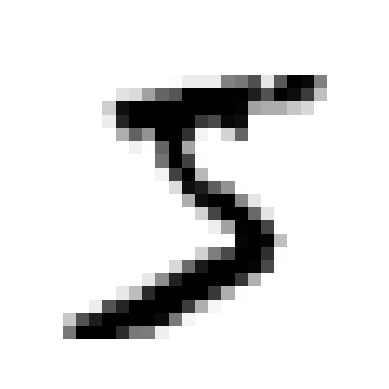

In [4]:
import matplotlib.pyplot as plt

def plot_digit(image_data):
	image = image_data.reshape(28, 28)
	plt.imshow(image, cmap="binary")
	plt.axis("off")
	
some_digit = X[0]
plot_digit(some_digit)
plt.show()

In [5]:
y[0]

'5'

In [6]:
X_train, X_test = X[:60000], X[60000:]
y_train, y_test = y[:60000], y[60000:]

## 2. Binary Classification

In [7]:
y_train_5 = (y_train == '5') # True for all 5s, False otherwise
y_test_5 = (y_test == '5')

In [8]:
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_5)

# Test it on our example digit
print(sgd_clf.predict([some_digit]))
# Output: array([True])

[ True]


## 4. Performance measures

In [9]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(sgd_clf, X_train, y_train, cv=3, scoring="accuracy")
print(scores)

[0.87365 0.85835 0.8689 ]


In [10]:
from sklearn.dummy import DummyClassifier

dummy_clf = DummyClassifier()
dummy_clf.fit(X_train, y_train_5)
dummy_scores = cross_val_score(dummy_clf, X_train, y_train_5, cv=3, scoring="accuracy")
print(dummy_scores)

[0.90965 0.90965 0.90965]


In [11]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix

y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3)
cm = confusion_matrix(y_train_5, y_train_pred)
print(cm)

[[53892   687]
 [ 1891  3530]]
